# Smart MCQ Solver — DL & GenAI Course Project
Roll No: 23f3000117



## 1. Imports, Reproducibility & Configuration

In [1]:

import os
import re
import gc
import html
import random
import warnings
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["TOKENIZERS_PARALLELISM"] = "false"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 50)
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Torch  : {torch.__version__}")
print("=" * 50)


Device : cuda
GPU    : Tesla T4
Torch  : 2.10.0+cu128


In [2]:
# -----------------------------
# Weights & Biases
# -----------------------------
import wandb

WANDB_PROJECT = "23f3000117-t22026"

wandb.login(key="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")

wandb.init(
    project=WANDB_PROJECT,
    name="Baseline",
    config={
        "seed": 42,
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 3,
        "max_length": 512,
        "weight_decay": 0.01,
        "num_folds": 5,
    }
)

print("W&B initialized successfully!")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aryansd9049 (aryansd9049-iit-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_085212-bqp80x7c
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Baseline
wandb: ⭐️ View project at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: 🚀 View run at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/bqp80x7c


W&B initialized successfully!


In [3]:

class Config:
    max_length = 256        # prompt + ONE option, so this can be shorter than before
    batch_size = 4           # each "example" internally expands to 5 sequences
    grad_accum_steps = 4
    epochs = 4
    learning_rate = 2e-5
    weight_decay = 0.01
    dropout = 0.2
    num_folds = 3             # keep CV light enough to fit a single Kaggle session
    seed = SEED
    model_name = "distilroberta-base"
    rag_top_k = 2              # how many retrieved snippets to prepend

CFG = Config()
OPTIONS = ["A", "B", "C", "D", "E"]
print("Configuration loaded.")


Configuration loaded.


## 2. Data Loading & EDA
Same as before — check the printed shapes below before trusting any batch-size assumptions further down.

Dataset Loaded Successfully
Train Shape : (2000, 8)
Test Shape  : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A



Answer Distribution


answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

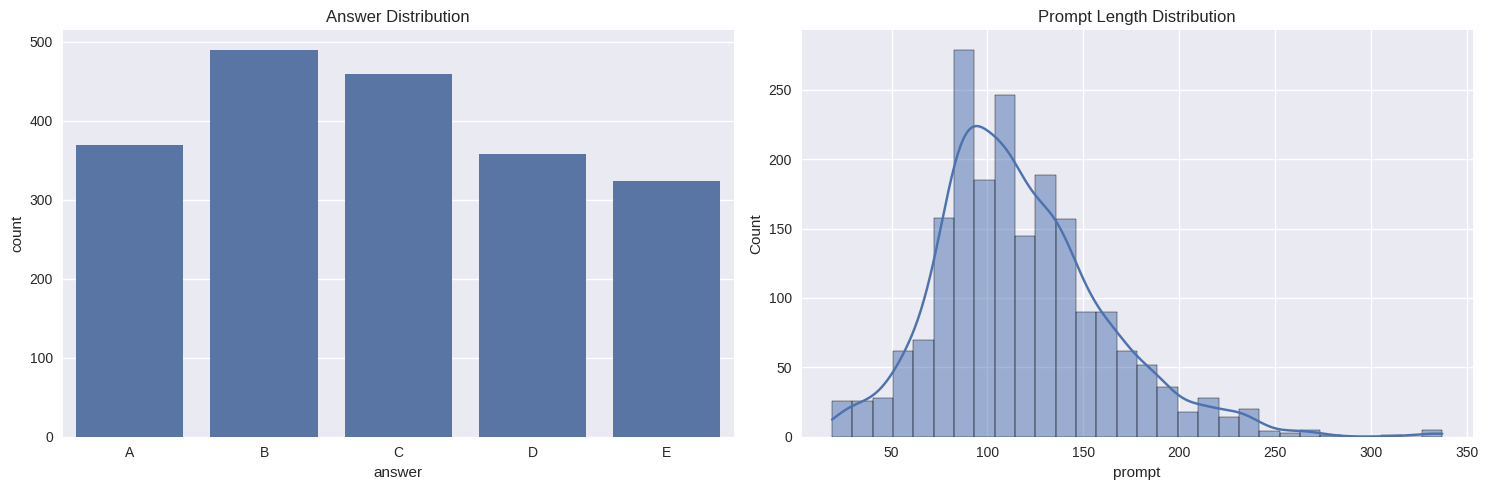

In [4]:

TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_SUB_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)
print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")

display(train_df.head())
print("\nAnswer Distribution")
display(train_df["answer"].value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=train_df, x="answer", order=sorted(train_df["answer"].unique()), ax=ax[0])
ax[0].set_title("Answer Distribution")
sns.histplot(train_df["prompt"].astype(str).str.len(), bins=30, kde=True, ax=ax[1])
ax[1].set_title("Prompt Length Distribution")
plt.tight_layout()
plt.show()


## 3. Preprocessing & the MAP@3 Metric

In [5]:

def clean_text(text) -> str:
    """Clean and normalize text."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


TEXT_COLUMNS = ["prompt", "A", "B", "C", "D", "E"]
for column in TEXT_COLUMNS:
    train_df[column] = train_df[column].astype(str).apply(clean_text)
    test_df[column] = test_df[column].astype(str).apply(clean_text)

label_map = {opt: i for i, opt in enumerate(OPTIONS)}
train_df["label"] = train_df["answer"].map(label_map)


def map_at_3(y_true, predictions) -> float:
    """Mean Average Precision @ 3 -- the competition metric."""
    score = 0.0
    for truth, pred in zip(y_true, predictions):
        if truth in pred:
            score += 1 / (pred.index(truth) + 1)
    return score / len(y_true)


print("Preprocessing done. Label counts:")
print(train_df["label"].value_counts().sort_index())


Preprocessing done. Label counts:
label
0    369
1    490
2    459
3    358
4    324
Name: count, dtype: int64


### 3a. Baseline: TF-IDF cosine similarity (Milestone 1)
A cheap, non-neural sanity check: does raw lexical overlap between the
prompt and each option already predict anything? This gives us a floor
to compare the transformer models against, and it's a fast, honest
answer to "what's the simplest thing you tried first?" in viva.

In [6]:

tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
tfidf_vectorizer.fit(pd.concat([train_df[c] for c in ["prompt", "A", "B", "C", "D", "E"]]))


def tfidf_top3(df: pd.DataFrame) -> List[List[str]]:
    preds = []
    prompt_vecs = tfidf_vectorizer.transform(df["prompt"])
    for i in range(len(df)):
        option_vecs = tfidf_vectorizer.transform([df.iloc[i][o] for o in OPTIONS])
        sims = cosine_similarity(prompt_vecs[i], option_vecs).flatten()
        order = np.argsort(sims)[::-1]
        preds.append([OPTIONS[j] for j in order[:3]])
    return preds


baseline_preds = tfidf_top3(train_df)
baseline_top1 = [p[0] for p in baseline_preds]
baseline_acc = accuracy_score(train_df["answer"], baseline_top1)
baseline_map3 = map_at_3(train_df["answer"].tolist(), baseline_preds)

print(f"TF-IDF baseline (on train, in-sample) | Accuracy: {baseline_acc:.4f} | MAP@3: {baseline_map3:.4f}")

wandb.init(project=WANDB_PROJECT, name="Baseline-TFIDF", reinit=True,
           config={"model": "tfidf_cosine_similarity"})
wandb.log({"accuracy": baseline_acc, "map@3": baseline_map3})
wandb.finish()


wandb: Finishing previous runs because reinit is set to True.


TF-IDF baseline (on train, in-sample) | Accuracy: 0.1395 | MAP@3: 0.2908


wandb: updating run metadata
wandb: 🚀 View run Baseline at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/bqp80x7c
wandb: ⭐️ View project at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260728_085212-bqp80x7c/logs
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run 4954whqz
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_085219-4954whqz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Baseline-TFIDF
wandb: ⭐️ View project at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: 🚀 View run at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/4954whqz
wandb: updating run metadata; uploading summary
wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb:    map@3 ▁
wandb: 

## 4. Pairwise MCQ Encoding

This is the key structural fix. Instead of one classification target over
5 positions, each question becomes **5 independent (prompt, option) pairs**.
The model scores each pair with a single number; the 5 scores for a
question are then compared with softmax + cross-entropy. This is exactly
what `AutoModelForMultipleChoice` expects, and it's also how we score our
from-scratch model, so both models share the same data pipeline.

In [7]:

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)


def tokenize_multiple_choice(df: pd.DataFrame, max_length: int, context_col: Optional[str] = None):
    """
    Builds (num_rows, 5, seq_len) tensors: row i, option j is the encoding
    of (prompt[i] [+ context[i]], option_j[i]).
    """
    first_sentences, second_sentences = [], []

    for _, row in df.iterrows():
        prompt = row["prompt"]
        if context_col is not None and context_col in df.columns and row[context_col]:
            prompt = row[context_col] + "\n\n" + prompt
        first_sentences.extend([prompt] * 5)
        second_sentences.extend([row[opt] for opt in OPTIONS])

    tokenized = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )

    n = len(df)
    input_ids = tokenized["input_ids"].view(n, 5, -1)
    attention_mask = tokenized["attention_mask"].view(n, 5, -1)
    return input_ids, attention_mask


class MCQPairwiseDataset(Dataset):
    """Yields (5, seq_len) tensors per question, ready for MC scoring."""

    def __init__(self, input_ids, attention_mask, labels=None):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return self.input_ids.size(0)

    def __getitem__(self, idx):
        item = {"input_ids": self.input_ids[idx], "attention_mask": self.attention_mask[idx]}
        if self.labels is not None:
            item["labels"] = self.labels[idx]
        return item


def mc_forward(model, input_ids, attention_mask, is_hf: bool):
    """Returns (batch, 5) logits regardless of whether `model` is an HF
    AutoModelForMultipleChoice or our custom scratch scorer."""
    if is_hf:
        return model(input_ids=input_ids, attention_mask=attention_mask).logits
    batch_size, num_choices, seq_len = input_ids.shape
    flat_ids = input_ids.view(-1, seq_len)
    flat_mask = attention_mask.view(-1, seq_len)
    scores = model(flat_ids, flat_mask)
    return scores.view(batch_size, num_choices)


print("Pairwise encoding utilities ready.")


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pairwise encoding utilities ready.


## 5. Model 1 — From-Scratch Attention Scorer

No pretrained weights anywhere: embeddings are randomly initialised and
trained from zero. We reuse the DistilRoBERTa tokenizer only for its
vocabulary (every project still needs *some* way to turn text into ids —
the model itself learns everything from scratch).

In [8]:

class MultiHeadAttention(nn.Module):
    """Multi-head self-attention implemented from scratch."""

    def __init__(self, embed_dim: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, t, _ = x.size()
        q = self.q_proj(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        probs = self.dropout(torch.softmax(scores, dim=-1))
        context = torch.matmul(probs, v).transpose(1, 2).contiguous().view(b, t, -1)
        return self.out_proj(context)


class CustomMCQScorer(nn.Module):
    """From-scratch model: embedding + self-attention + pooling + MLP,
    outputs ONE relevance score for a (prompt, option) pair."""

    def __init__(self, vocab_size: int, embed_dim: int = 192, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.attention = MultiHeadAttention(embed_dim, num_heads=4, dropout=dropout)
        self.norm = nn.LayerNorm(embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.out = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.norm(x + self.attention(x))
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        x = self.dropout(pooled)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.out(x).squeeze(-1)


print("From-scratch model defined.")


From-scratch model defined.


## 6. Shared K-Fold Training Loop
Used by all three models so the comparison in Section 9 is apples-to-apples.

In [9]:

def train_kfold_mc(model_builder, train_df, test_df, cfg, run_name, is_hf, context_col=None):
    """
    Trains `model_builder()` with `cfg.num_folds`-fold stratified CV.
    Logs a real W&B run per fold, keeps the best epoch per fold, and
    returns:
      oof_probs  -- (len(train_df), 5) out-of-fold probabilities
      test_probs -- (len(test_df), 5) fold-averaged test probabilities
    """
    skf = StratifiedKFold(n_splits=cfg.num_folds, shuffle=True, random_state=cfg.seed)
    oof_probs = np.zeros((len(train_df), 5))
    test_probs = np.zeros((len(test_df), 5))
    fold_scores = []

    test_ids, test_mask = tokenize_multiple_choice(test_df, cfg.max_length, context_col)
    test_loader = DataLoader(MCQPairwiseDataset(test_ids, test_mask), batch_size=cfg.batch_size * 2, shuffle=False)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df["label"])):
        print(f"\n===== {run_name} | Fold {fold + 1}/{cfg.num_folds} =====")

        fold_train = train_df.iloc[tr_idx].reset_index(drop=True)
        fold_val = train_df.iloc[va_idx].reset_index(drop=True)

        tr_ids, tr_mask = tokenize_multiple_choice(fold_train, cfg.max_length, context_col)
        va_ids, va_mask = tokenize_multiple_choice(fold_val, cfg.max_length, context_col)
        tr_labels = torch.tensor(fold_train["label"].values, dtype=torch.long)
        va_labels = torch.tensor(fold_val["label"].values, dtype=torch.long)

        train_loader = DataLoader(MCQPairwiseDataset(tr_ids, tr_mask, tr_labels), batch_size=cfg.batch_size, shuffle=True)
        val_loader = DataLoader(MCQPairwiseDataset(va_ids, va_mask, va_labels), batch_size=cfg.batch_size * 2, shuffle=False)

        model = model_builder().to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
        total_steps = max(1, (len(train_loader) // cfg.grad_accum_steps + 1) * cfg.epochs)
        scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
        scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

        wandb.init(project=WANDB_PROJECT, name=f"{run_name}-fold{fold + 1}", reinit=True,
                   config={"model": run_name, "fold": fold + 1, "epochs": cfg.epochs,
                           "lr": cfg.learning_rate, "batch_size": cfg.batch_size,
                           "max_length": cfg.max_length})

        best_val_acc, best_state, best_val_probs = 0.0, None, None

        for epoch in range(cfg.epochs):
            model.train()
            running_loss = 0.0
            optimizer.zero_grad()

            for step, batch in enumerate(tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}")):
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = mc_forward(model, input_ids, attention_mask, is_hf)
                    loss = F.cross_entropy(logits, labels) / cfg.grad_accum_steps

                scaler.scale(loss).backward()
                running_loss += loss.item() * cfg.grad_accum_steps

                if (step + 1) % cfg.grad_accum_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()

            model.eval()
            val_logits_all, val_labels_all = [], []
            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(DEVICE)
                    attention_mask = batch["attention_mask"].to(DEVICE)
                    logits = mc_forward(model, input_ids, attention_mask, is_hf)
                    val_logits_all.append(logits.cpu())
                    val_labels_all.append(batch["labels"])

            val_logits_all = torch.cat(val_logits_all)
            val_labels_all = torch.cat(val_labels_all)
            val_probs = torch.softmax(val_logits_all, dim=-1).numpy()
            val_preds = val_probs.argmax(axis=1)

            val_acc = accuracy_score(val_labels_all.numpy(), val_preds)
            val_f1 = f1_score(val_labels_all.numpy(), val_preds, average="macro")
            avg_loss = running_loss / len(train_loader)

            print(f"Fold {fold+1} Epoch {epoch+1} | Loss {avg_loss:.4f} | Val Acc {val_acc:.4f} | Val Macro-F1 {val_f1:.4f}")
            wandb.log({"epoch": epoch + 1, "train_loss": avg_loss, "val_accuracy": val_acc, "val_macro_f1": val_f1})

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_val_probs = val_probs

        model.load_state_dict(best_state)
        oof_probs[va_idx] = best_val_probs
        fold_scores.append(best_val_acc)

        model.eval()
        fold_test_probs = []
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                logits = mc_forward(model, input_ids, attention_mask, is_hf)
                fold_test_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        test_probs += np.concatenate(fold_test_probs) / cfg.num_folds

        wandb.finish()
        del model, best_state
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\n{run_name} | mean fold val accuracy: {np.mean(fold_scores):.4f}")
    return oof_probs, test_probs


## 7. Train Model 1 (Scratch) and Model 2 (Pretrained)

In [10]:

oof_scratch, test_scratch = train_kfold_mc(
    model_builder=lambda: CustomMCQScorer(vocab_size=tokenizer.vocab_size),
    train_df=train_df, test_df=test_df, cfg=CFG,
    run_name="Scratch-Attention", is_hf=False,
)



===== Scratch-Attention | Fold 1/3 =====


wandb: setting up run 4vfs1kkh
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_085228-4vfs1kkh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Scratch-Attention-fold1
wandb: ⭐️ View project at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: 🚀 View run at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/4vfs1kkh


Fold 1 Epoch 1:   0%|          | 0/334 [00:00<?, ?it/s]

Fold 1 Epoch 1 | Loss 2.3639 | Val Acc 0.2804 | Val Macro-F1 0.2743


Fold 1 Epoch 2:   0%|          | 0/334 [00:00<?, ?it/s]

...

Fold 3 Epoch 3 | Loss 1.8973 | Val Acc 0.2958 | Val Macro-F1 0.2947


Fold 3 Epoch 4:   0%|          | 0/334 [00:00<?, ?it/s]

Fold 3 Epoch 4 | Loss 1.8936 | Val Acc 0.3048 | Val Macro-F1 0.3044


wandb: updating run metadata
wandb: uploading history steps 0-3, summary, console lines 1-3
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▆█
wandb:   train_loss █▅▁▁
wandb: val_accuracy ▁█▅▇
wandb: val_macro_f1 ▁█▅▇
wandb: 
wandb: Run summary:
wandb:        epoch 4
wandb:   train_loss 1.89363
wandb: val_accuracy 0.3048
wandb: val_macro_f1 0.30442
wandb: 
wandb: 🚀 View run Scratch-Attention-fold3 at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/qyrb5i1g
wandb: ⭐️ View project at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260728_085304-qyrb5i1g/logs



Scratch-Attention | mean fold val accuracy: 0.3620


In [11]:

oof_pretrained, test_pretrained = train_kfold_mc(
    model_builder=lambda: AutoModelForMultipleChoice.from_pretrained(CFG.model_name),
    train_df=train_df, test_df=test_df, cfg=CFG,
    run_name="DistilRoBERTa-MC", is_hf=True,
)



===== DistilRoBERTa-MC | Fold 1/3 =====


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaForMultipleChoice LOAD REPORT from: distilroberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: setting up run 37cps3oo
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_085327-37cps3oo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run DistilRoBERTa-MC-fold1
wandb: ⭐️ View project at https://wandb.ai/aryansd9049-iit

Fold 1 Epoch 1:   0%|          | 0/334 [00:00<?, ?it/s]

...

Fold 3 Epoch 3 | Loss 0.6189 | Val Acc 0.9309 | Val Macro-F1 0.9293


Fold 3 Epoch 4:   0%|          | 0/334 [00:00<?, ?it/s]

Fold 3 Epoch 4 | Loss 0.4908 | Val Acc 0.9369 | Val Macro-F1 0.9353


wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▆█
wandb:   train_loss █▄▂▁
wandb: val_accuracy ▁▇██
wandb: val_macro_f1 ▁▇██
wandb: 
wandb: Run summary:
wandb:        epoch 4
wandb:   train_loss 0.49075
wandb: val_accuracy 0.93694
wandb: val_macro_f1 0.93528
wandb: 
wandb: 🚀 View run DistilRoBERTa-MC-fold3 at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/g4o02nko
wandb: ⭐️ View project at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260728_090253-g4o02nko/logs



DistilRoBERTa-MC | mean fold val accuracy: 0.9135


## 8. Model 3 — RAG-Augmented Pretrained Model

For each question, retrieve the most similar *other* training questions
(by sentence-embedding similarity) and prepend them as context before the
prompt. The index is built only from the training split so the model
never sees validation/test content while retrieving.

In [12]:

try:
    from sentence_transformers import SentenceTransformer
    import faiss
except Exception as exc:
    SentenceTransformer, faiss = None, None
    print(f"sentence-transformers/faiss unavailable: {exc}")


def build_context_column(source_df: pd.DataFrame, query_df: pd.DataFrame, top_k: int, exclude_self: bool):
    """Returns a list of retrieved-context strings, one per row of query_df."""
    if SentenceTransformer is None or faiss is None:
        return ["" for _ in range(len(query_df))]

    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    corpus_text = source_df["prompt"].tolist()
    corpus_emb = embedder.encode(corpus_text, convert_to_numpy=True, show_progress_bar=False)
    index = faiss.IndexFlatL2(corpus_emb.shape[1])
    index.add(corpus_emb)

    query_emb = embedder.encode(query_df["prompt"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    k = top_k + 1 if exclude_self else top_k
    _, neighbours = index.search(query_emb, k)

    contexts = []
    for row_pos, neighbour_ids in enumerate(neighbours):
        picked = []
        for nid in neighbour_ids:
            if exclude_self and corpus_text[nid] == query_df.iloc[row_pos]["prompt"]:
                continue
            picked.append(corpus_text[nid])
            if len(picked) == top_k:
                break
        contexts.append(" | ".join(picked))
    return contexts


train_df["rag_context"] = build_context_column(train_df, train_df, CFG.rag_top_k, exclude_self=True)
test_df["rag_context"] = build_context_column(train_df, test_df, CFG.rag_top_k, exclude_self=False)

print(train_df[["prompt", "rag_context"]].head(2))


sentence-transformers/faiss unavailable: No module named 'faiss'
                                              prompt rag_context
0  Pick the best possible answer: What is Martin ...            
1        What is accelerator-based light-ion fusion?            


In [13]:

oof_rag, test_rag = train_kfold_mc(
    model_builder=lambda: AutoModelForMultipleChoice.from_pretrained(CFG.model_name),
    train_df=train_df, test_df=test_df, cfg=CFG,
    run_name="RAG-DistilRoBERTa-MC", is_hf=True, context_col="rag_context",
)



===== RAG-DistilRoBERTa-MC | Fold 1/3 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaForMultipleChoice LOAD REPORT from: distilroberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: setting up run u5pix1fs
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_090743-u5pix1fs
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run RAG-DistilRoBERTa-MC-fold1
wandb: ⭐️ View project at https://wandb.ai/aryansd9049

Fold 1 Epoch 1:   0%|          | 0/334 [00:00<?, ?it/s]

Fold 1 Epoch 1 | Loss 1.5182 | Val Acc 0.5727 | Val Macro-F1 0.5694


...

Fold 3 Epoch 3 | Loss 0.6430 | Val Acc 0.9054 | Val Macro-F1 0.9040


Fold 3 Epoch 4:   0%|          | 0/334 [00:00<?, ?it/s]

Fold 3 Epoch 4 | Loss 0.5007 | Val Acc 0.9054 | Val Macro-F1 0.9033


wandb: updating run metadata
wandb: uploading config.yaml; uploading output.log; uploading wandb-summary.json
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▆█
wandb:   train_loss █▅▂▁
wandb: val_accuracy ▁▇██
wandb: val_macro_f1 ▁▇██
wandb: 
wandb: Run summary:
wandb:        epoch 4
wandb:   train_loss 0.50068
wandb: val_accuracy 0.90541
wandb: val_macro_f1 0.90327
wandb: 
wandb: 🚀 View run RAG-DistilRoBERTa-MC-fold3 at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/ropb0uxq
wandb: ⭐️ View project at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260728_091748-ropb0uxq/logs



RAG-DistilRoBERTa-MC | mean fold val accuracy: 0.9095


## 9. Comparing the Three Models (Milestone: ≥ 3 runs compared)

,model,accuracy,macro_f1,map@3
0,Scratch-Attention,0.3620,0.360356,0.533083
1,DistilRoBERTa-MC,0.9135,0.911565,0.944417
2,RAG-DistilRoBERTa-MC,0.9095,0.907101,0.942667


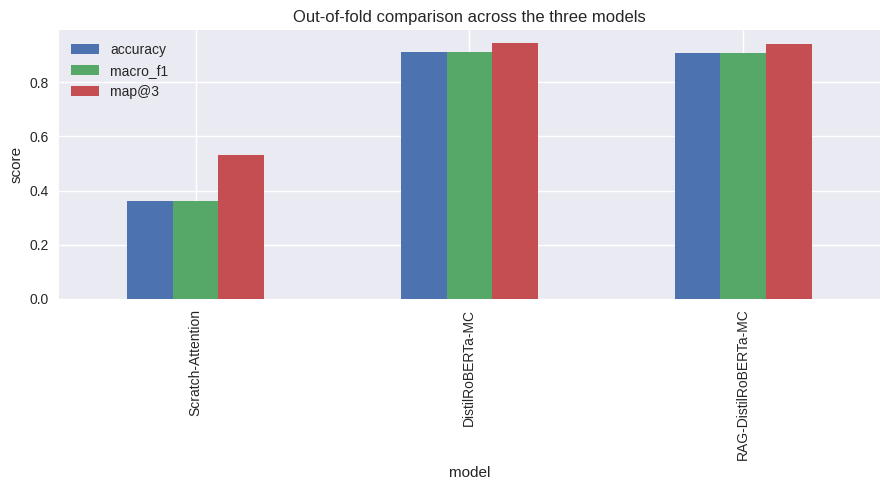

In [14]:

def summarize(name, oof_probs):
    preds = oof_probs.argmax(axis=1)
    top3 = [[OPTIONS[i] for i in row] for row in np.argsort(oof_probs, axis=1)[:, ::-1][:, :3]]
    acc = accuracy_score(train_df["label"], preds)
    f1 = f1_score(train_df["label"], preds, average="macro")
    map3 = map_at_3(train_df["answer"].tolist(), top3)
    return {"model": name, "accuracy": acc, "macro_f1": f1, "map@3": map3}


results = pd.DataFrame([
    summarize("Scratch-Attention", oof_scratch),
    summarize("DistilRoBERTa-MC", oof_pretrained),
    summarize("RAG-DistilRoBERTa-MC", oof_rag),
])
display(results)

results.set_index("model")[["accuracy", "macro_f1", "map@3"]].plot(kind="bar", figsize=(9, 5))
plt.title("Out-of-fold comparison across the three models")
plt.ylabel("score")
plt.tight_layout()
plt.show()


## 10. Ensembling & Final Submission (Milestone 5)

Weight each model by its out-of-fold macro-F1 (better OOF models get more
say), average their test-set probabilities, then take the top-3 options
per question.

In [15]:

weights = {
    "Scratch-Attention": f1_score(train_df["label"], oof_scratch.argmax(axis=1), average="macro"),
    "DistilRoBERTa-MC": f1_score(train_df["label"], oof_pretrained.argmax(axis=1), average="macro"),
    "RAG-DistilRoBERTa-MC": f1_score(train_df["label"], oof_rag.argmax(axis=1), average="macro"),
}
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}
print("Ensemble weights (from OOF macro-F1):", weights)

ensemble_oof = (
    weights["Scratch-Attention"] * oof_scratch
    + weights["DistilRoBERTa-MC"] * oof_pretrained
    + weights["RAG-DistilRoBERTa-MC"] * oof_rag
)
ensemble_test = (
    weights["Scratch-Attention"] * test_scratch
    + weights["DistilRoBERTa-MC"] * test_pretrained
    + weights["RAG-DistilRoBERTa-MC"] * test_rag
)

ensemble_oof_top3 = [[OPTIONS[i] for i in row] for row in np.argsort(ensemble_oof, axis=1)[:, ::-1][:, :3]]
ensemble_oof_acc = accuracy_score(train_df["label"], ensemble_oof.argmax(axis=1))
ensemble_oof_map3 = map_at_3(train_df["answer"].tolist(), ensemble_oof_top3)
print(f"Ensembled OOF | Accuracy: {ensemble_oof_acc:.4f} | MAP@3: {ensemble_oof_map3:.4f}")

wandb.init(project=WANDB_PROJECT, name="Ensemble-Final", reinit=True, config={"weights": weights})
wandb.log({"oof_accuracy": ensemble_oof_acc, "oof_map@3": ensemble_oof_map3})
wandb.finish()


Ensemble weights (from OOF macro-F1): {'Scratch-Attention': 0.1653749322021213, 'DistilRoBERTa-MC': 0.4183369489288283, 'RAG-DistilRoBERTa-MC': 0.4162881188690505}
Ensembled OOF | Accuracy: 0.9285 | MAP@3: 0.9541


wandb: setting up run nl6r59c0
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260728_092229-nl6r59c0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Ensemble-Final
wandb: ⭐️ View project at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: 🚀 View run at https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/nl6r59c0
wandb: updating run metadata; uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: oof_accuracy ▁
wandb:    oof_map@3 ▁
wandb: 
wandb: Run summary:
wandb: oof_accuracy 0.9285
wandb:    oof_map@3 0.95408
wandb: 
wandb: 🚀 View run Ensemble-Final at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026/runs/nl6r59c0
wandb: ⭐️ View project at: https://wandb.ai/aryansd9049-iit-/23f3000117-t22026
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260728_092229-nl6r59c0/logs


In [16]:

test_top3 = [[OPTIONS[i] for i in row] for row in np.argsort(ensemble_test, axis=1)[:, ::-1][:, :3]]
test_top3_strings = [" ".join(row) for row in test_top3]

submission = sample_sub.copy()
submission.iloc[:, 1] = test_top3_strings
submission.to_csv("submission.csv", index=False)

print("Submission preview:")
display(submission.head())
print("\nsubmission.csv saved.")


Submission preview:


,ID,Prediction
0,1,A D B
1,2,B E D
2,3,B E D
3,4,E C D
4,5,C A B



submission.csv saved.
